# Analyse du dataset **Speed Dating**
### Jedha — Bloc 2 | Birane WANE

**Question métier.**  
Quels facteurs augmentent la probabilité qu'un speed date débouche sur une **décision positive** (`dec`) puis sur un **match mutuel** (`match`) ?

**Angle d'analyse.**  
Le notebook adopte une lecture **orientée produit** : il distingue ce qui relève du **profil avant la rencontre** (préférences, variables de contexte, caractéristiques démographiques) de ce qui se construit **pendant l'interaction** (attractivité perçue, plaisir de l'échange, intérêts partagés, appréciation globale).

**Ce que contient ce notebook.**
1. une lecture rigoureuse de la structure du dataset ;
2. une analyse descriptive alignée avec le brief ;
3. des interprétations business formulées pour un cas d'usage type application de rencontre ;
4. un bonus de modélisation léger pour comparer le pouvoir explicatif du **profil** et de l'**interaction**.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

def find_file(candidates):
    """Return the first matching file found in common project locations."""
    cwd = Path.cwd()
    search_roots = [
        cwd,
        cwd / "data",
        cwd / "notebooks",
        cwd.parent,
        cwd.parent / "data",
        cwd / "SPEED DATING PROJET_BLOC 2",
        cwd / "BLOC 2_PROJET_SPEED DATING_Jedha Birane",
        cwd / "speed-dating-tinder-analysis",
        Path("/mnt/data"),
        Path("/mnt/data/SPEED DATING PROJET_BLOC 2"),
        Path("/mnt/data/BLOC 2_PROJET_SPEED DATING_Jedha Birane"),
        Path("/mnt/data/speed-dating-tinder-analysis"),
        Path("/mnt/data/speed-dating-tinder-analysis/data"),
    ]
    for root in search_roots:
        for name in candidates:
            p = root / name
            if p.exists():
                return p
    raise FileNotFoundError(f"Impossible de trouver un fichier parmi : {candidates}")

DATA_PATH = find_file([
    "speed_dating_data.csv",
    "Speed+Dating+Data (1).csv",
    "Speed+Dating+Data.csv",
])
KEY_PATH = find_file([
    "speed_dating_data_key.doc",
    "Speed+Dating+Data+Key.doc",
    "Speed+Dating+Data+Key (1).doc",
])

print("Dataset trouvé :", DATA_PATH)
print("Data key trouvé :", KEY_PATH)


Dataset trouvé : data/speed_dating_data.csv
Data key trouvé : data/speed_dating_data_key.doc


## 1. Chargement des données et compréhension de la structure

**Point méthodologique clé.**  
Chaque ligne correspond à la **perception d'un participant pour un rendez-vous donné**.  
Un même speed date apparaît donc généralement **deux fois** dans la table :
- une fois du point de vue de la personne A ;
- une fois du point de vue de la personne B.

Cette particularité n'est pas un problème, mais elle doit être explicitée avant toute lecture des KPI.


In [ ]:
df = pd.read_csv(DATA_PATH, encoding="latin1")
print("Shape :", df.shape)
display(df.head(3))

tmp = df[['wave','iid','pid','match']].dropna(subset=['pid']).copy()
tmp['pair_id'] = tmp.apply(lambda r: f"{int(r.wave)}_{min(int(r.iid), int(r.pid))}_{max(int(r.iid), int(r.pid))}", axis=1)
pair_df = tmp.drop_duplicates('pair_id')

summary_df = pd.DataFrame({
    "metric": [
        "Rows in dataset",
        "Unique speed dates",
        "Unique participants",
        "Number of waves",
        "Row-level match rate",
        "Decision yes rate (`dec`)"
    ],
    "value": [
        len(df),
        len(pair_df),
        df['iid'].nunique(),
        df['wave'].nunique(),
        round(df['match'].mean()*100, 2),
        round(df['dec'].mean()*100, 2),
    ]
})
display(summary_df)

Shape : (8378, 195)


,iid,id,gender,idg,condtn,wave,round,position,positin1,order,partner,pid,match,int_corr,samerace,age_o,race_o,pf_o_att,pf_o_sin,pf_o_int,pf_o_fun,pf_o_amb,pf_o_sha,dec_o,attr_o,sinc_o,intel_o,fun_o,amb_o,shar_o,like_o,prob_o,met_o,age,field,field_cd,undergra,mn_sat,tuition,race,imprace,imprelig,from,zipcode,income,goal,date,go_out,career,career_c,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,exphappy,expnum,attr1_1,sinc1_1,intel1_1,fun1_1,amb1_1,shar1_1,attr4_1,sinc4_1,intel4_1,fun4_1,amb4_1,shar4_1,attr2_1,sinc2_1,intel2_1,fun2_1,amb2_1,shar2_1,attr3_1,sinc3_1,fun3_1,intel3_1,amb3_1,attr5_1,sinc5_1,intel5_1,fun5_1,amb5_1,dec,attr,sinc,intel,fun,amb,shar,like,prob,met,match_es,attr1_s,sinc1_s,intel1_s,fun1_s,amb1_s,shar1_s,attr3_s,sinc3_s,intel3_s,fun3_s,amb3_s,satis_2,length,numdat_2,attr7_2,sinc7_2,intel7_2,fun7_2,amb7_2,shar7_2,attr1_2,sinc1_2,intel1_2,fun1_2,amb1_2,shar1_2,attr4_2,sinc4_2,intel4_2,fun4_2,amb4_2,shar4_2,attr2_2,sinc2_2,intel2_2,fun2_2,amb2_2,shar2_2,attr3_2,sinc3_2,intel3_2,fun3_2,amb3_2,attr5_2,sinc5_2,intel5_2,fun5_2,amb5_2,you_call,them_cal,date_3,numdat_3,num_in_3,attr1_3,sinc1_3,intel1_3,fun1_3,amb1_3,shar1_3,attr7_3,sinc7_3,intel7_3,fun7_3,amb7_3,shar7_3,attr4_3,sinc4_3,intel4_3,fun4_3,amb4_3,shar4_3,attr2_3,sinc2_3,intel2_3,fun2_3,amb2_3,shar2_3,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,1,11.0,0,0.14,0,27.0,2.0,35.0,20.0,20.0,20.0,0.0,5.0,0,6.0,8.0,8.0,8.0,8.0,6.0,7.0,4.0,2.0,21.0,Law,1.0,NaN,NaN,NaN,4.0,2.0,4.0,Chicago,"60,521","69,487.00",2.0,7.0,1.0,lawyer,NaN,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,3.0,2.0,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,35.0,20.0,15.0,20.0,5.0,5.0,6.0,8.0,8.0,8.0,7.0,NaN,NaN,NaN,NaN,NaN,1,6.0,9.0,7.0,7.0,6.0,5.0,7.0,6.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,19.44,16.67,13.89,22.22,11.11,16.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,7.0,8.0,7.0,6.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,2,12.0,0,0.54,0,22.0,2.0,60.0,0.0,0.0,40.0,0.0,0.0,0,7.0,8.0,10.0,7.0,7.0,5.0,8.0,4.0,2.0,21.0,Law,1.0,NaN,NaN,NaN,4.0,2.0,4.0,Chicago,"60,521","69,487.00",2.0,7.0,1.0,lawyer,NaN,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,3.0,2.0,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,35.0,20.0,15.0,20.0,5.0,5.0,6.0,8.0,8.0,8.0,7.0,NaN,NaN,NaN,NaN,NaN,1,7.0,8.0,7.0,8.0,5.0,6.0,7.0,5.0,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,19.44,16.67,13.89,22.22,11.11,16.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,7.0,8.0,7.0,6.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,3,13.0,1,0.16,1,22.0,4.0,19.0,18.0,19.0,18.0,14.0,12.0,1,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,1.0,21.0,Law,1.0,NaN,NaN,NaN,4.0,2.0,4.0,Chicago,"60,521","69,487.00",2.0,7.0,1.0,lawyer,NaN,9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,3.0,2.0,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,35.0,20.0,15.0,20.0,5.0,5.0,6.0,8.0,8.0,8.0,7.0,NaN,NaN,NaN,NaN,NaN,1,5.0,8.0,9.0,8.0,5.0,7.0,7.0,NaN,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,19.44,16.67,13.89,22.22,11.11,16.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,7.0,8.0,7.0,6.0,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,NaN,NaN,15.0,20.0,20.0,15.0,15.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


,metric,value
0,Rows in dataset,8378.00
1,Unique speed dates,4184.00
2,Unique participants,551.00
3,Number of waves,21.00
4,Row-level match rate,16.47
5,Decision yes rate (`dec`),41.99


## 1.1. Bien définir l'unité d'analyse

Le dataset peut être lu à **trois niveaux complémentaires** :

- **niveau ligne** : la perception d'un participant pour un rendez-vous précis ;
- **niveau participant** : ses taux moyens, ses attentes et son auto-évaluation ;
- **niveau paire** : le rendez-vous réel entre deux personnes.

Cette distinction conditionne la bonne interprétation de `dec` et `match`.


In [ ]:
work = df.copy()
work['pair_low'] = work[['iid','pid']].min(axis=1)
work['pair_high'] = work[['iid','pid']].max(axis=1)
work['age_gap'] = (work['age'] - work['age_o']).abs()

pair_df = (
    work.groupby(['wave','pair_low','pair_high'])
        .agg(
            match=('match','first'),
            samerace=('samerace','first'),
            shar_pair=('shar','mean'),
            attr_pair=('attr','mean'),
            fun_pair=('fun','mean'),
            like_pair=('like','mean'),
            age_gap=('age_gap','mean')
        )
        .reset_index()
)

analysis_levels = pd.DataFrame({
    'Niveau': ['Ligne (perception individuelle)', 'Participant', 'Paire (date réel)'],
    'Volume': [len(df), df['iid'].nunique(), len(pair_df)],
    'Exemple de variable cible': ['dec', 'taux moyen de match', 'match'],
    'Lecture': [
        'Une personne évalue un date',
        'On résume le comportement d’un individu sur toute la soirée',
        'On observe un rendez-vous unique entre deux personnes'
    ]
})

display(analysis_levels)
print("Taux de match au niveau ligne :", f"{df['match'].mean():.2%}")
print("Taux de match au niveau paire :", f"{pair_df['match'].mean():.2%}")

,Niveau,Volume,Exemple de variable cible,Lecture
0,Ligne (perception individuelle),8378,dec,Une personne évalue un date
1,Participant,551,taux moyen de match,On résume le comportement d’un individu sur to...
2,Paire (date réel),4194,match,On observe un rendez-vous unique entre deux pe...


Taux de match au niveau ligne : 16.47%
Taux de match au niveau paire : 16.45%


### Pourquoi cette distinction est utile

- `dec` se lit naturellement au **niveau ligne**, car il s'agit d'une décision individuelle ;
- `match` peut être lu au **niveau ligne** pour les KPI globaux, mais aussi au **niveau paire** pour certains contrôles de robustesse ;
- raisonner explicitement sur ces niveaux évite de surinterpréter des résultats produits sur des observations dupliquées par construction.


## 2. Qualité des données

Avant de commenter les résultats, on vérifie :
- la structure générale du dataset ;
- les types de variables ;
- les valeurs manquantes ;
- les doublons exacts ;
- la disponibilité réelle des colonnes utiles pour chaque question du brief.

L'objectif n'est pas de forcer un nettoyage artificiel, mais de documenter clairement ce qui est exploitable et ce qui ne l'est pas.


<class 'pandas.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 195 entries, iid to amb5_3
dtypes: float64(174), int64(13), str(8)
memory usage: 12.5 MB


None

Nombre de doublons exacts : 0


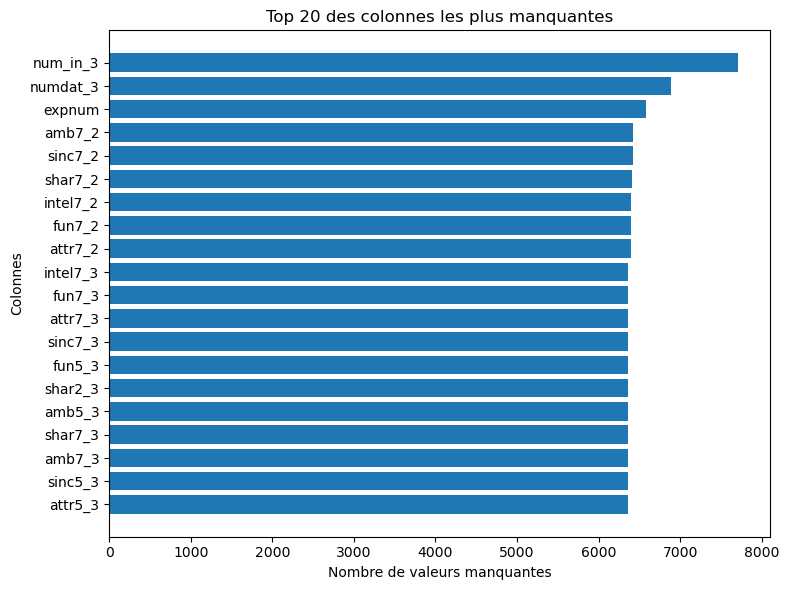

,missing_values
num_in_3,7710
numdat_3,6882
expnum,6578
sinc7_2,6423
amb7_2,6423
shar7_2,6404
attr7_2,6394
fun7_2,6394
intel7_2,6394
fun5_3,6362


In [ ]:
display(df.info())

na_counts = df.isna().sum().sort_values(ascending=False)
dupes = df.duplicated().sum()
print("Nombre de doublons exacts :", dupes)

na_top20 = na_counts.head(20).sort_values(ascending=True)

plt.figure(figsize=(8,6))
plt.barh(na_top20.index, na_top20.values)
plt.title("Top 20 des colonnes les plus manquantes")
plt.xlabel("Nombre de valeurs manquantes")
plt.ylabel("Colonnes")
plt.tight_layout()
plt.show()

display(na_counts.head(20).to_frame("missing_values"))

## 3. Définir correctement les deux cibles : `dec` et `match`

Deux variables jouent un rôle central dans le projet :

- **`dec`** : le participant souhaite revoir la personne ;
- **`match`** : les deux participants souhaitent se revoir.

Dans une logique produit, `dec` mesure un **intérêt individuel**, tandis que `match` mesure la **réciprocité**.  
La distinction est essentielle : un bon yes rate individuel ne garantit pas un bon taux de match.


,n,yes_rate,match_rate,age_mean
gender,,,,
Femmes,4184,36.54%,16.49%,26.11
Hommes,4194,47.42%,16.45%,26.61


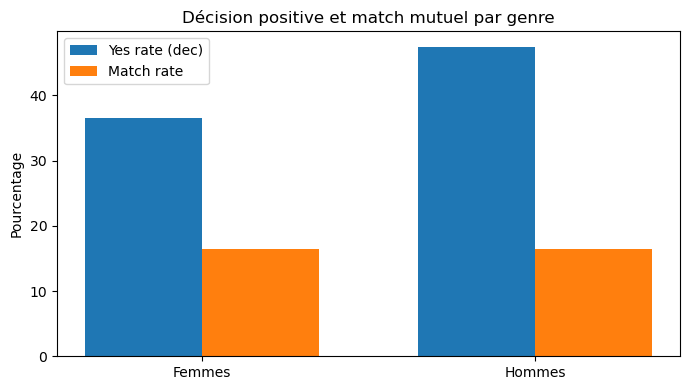

In [ ]:
gender_summary = (
    df.groupby('gender')
      .agg(
          n=('match','size'),
          yes_rate=('dec','mean'),
          match_rate=('match','mean'),
          age_mean=('age','mean')
      )
      .rename(index={0:'Femmes', 1:'Hommes'})
)

display(gender_summary.style.format({
    'yes_rate': '{:.2%}',
    'match_rate': '{:.2%}',
    'age_mean': '{:.2f}'
}))

plot_df = gender_summary[['yes_rate', 'match_rate']].copy() * 100
x = np.arange(len(plot_df.index))
width = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - width/2, plot_df['yes_rate'], width, label='Yes rate (dec)')
plt.bar(x + width/2, plot_df['match_rate'], width, label='Match rate')
plt.xticks(x, plot_df.index)
plt.ylabel("Pourcentage")
plt.title("Décision positive et match mutuel par genre")
plt.legend()
plt.tight_layout()
plt.show()

### Première lecture des KPI

Le tableau et le graphique ci-dessous permettent de comparer les décisions positives et les matches selon le genre.

Le point important à observer est le suivant :
- le comportement de réponse individuelle peut différer fortement ;
- mais le résultat final réciproque peut rester proche.


## 3.1. Vérification de robustesse au niveau participant

Comme un même participant apparaît plusieurs fois dans le dataset, il est utile de compléter la lecture ligne par ligne par une lecture **par participant**.

On calcule donc, pour chaque individu :
- son **yes rate moyen** ;
- son **match rate moyen** ;
- puis on compare la distribution de ces taux selon le genre.


,Metric,Genre,Moyenne,IC95 bas,IC95 haut,n participants
0,yes_rate,Femmes,37.38%,34.54%,40.22%,274
1,yes_rate,Hommes,48.11%,45.04%,51.18%,277
2,match_rate,Femmes,16.87%,15.09%,18.64%,274
3,match_rate,Hommes,16.92%,15.15%,18.69%,277


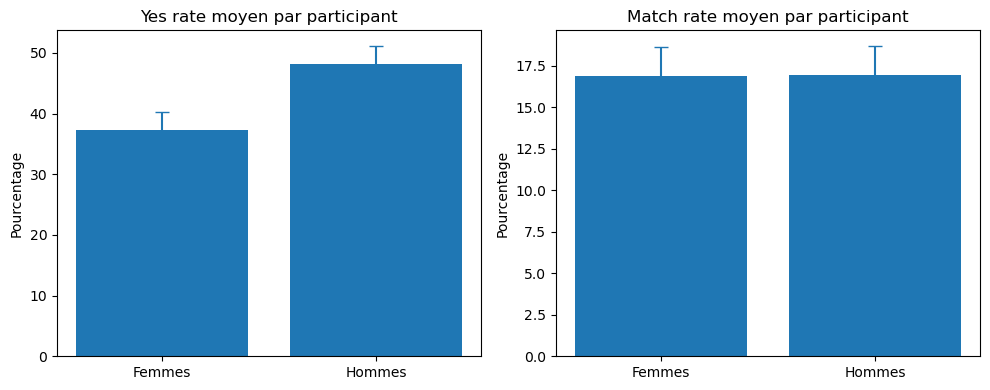

In [ ]:
participant_rates = (
    df.groupby(['iid','gender'])
      .agg(
          yes_rate=('dec','mean'),
          match_rate=('match','mean'),
          n_dates=('dec','size')
      )
      .reset_index()
)

rows = []
for metric in ['yes_rate', 'match_rate']:
    for g, label in [(0, 'Femmes'), (1, 'Hommes')]:
        x = participant_rates.loc[participant_rates['gender'] == g, metric].dropna()
        mean = x.mean()
        se = x.std(ddof=1) / np.sqrt(len(x))
        ci_low = mean - 1.96 * se
        ci_high = mean + 1.96 * se
        rows.append({
            'Metric': metric,
            'Genre': label,
            'Moyenne': mean,
            'IC95 bas': ci_low,
            'IC95 haut': ci_high,
            'n participants': len(x)
        })

participant_ci = pd.DataFrame(rows)
display(participant_ci.style.format({'Moyenne':'{:.2%}','IC95 bas':'{:.2%}','IC95 haut':'{:.2%}'}))

fig, axes = plt.subplots(1, 2, figsize=(10,4))
for ax, metric, title in zip(axes, ['yes_rate','match_rate'], ['Yes rate moyen par participant', 'Match rate moyen par participant']):
    sub = participant_ci[participant_ci['Metric'] == metric].copy()
    ax.bar(sub['Genre'], sub['Moyenne']*100)
    ax.errorbar(sub['Genre'], sub['Moyenne']*100,
                yerr=[(sub['Moyenne']-sub['IC95 bas'])*100, (sub['IC95 haut']-sub['Moyenne'])*100],
                fmt='none', capsize=5)
    ax.set_ylabel("Pourcentage")
    ax.set_title(title)
plt.tight_layout()
plt.show()

### Interprétation

Cette vérification vise à s'assurer que le message observé plus haut ne vient pas simplement du fait qu'une même personne apparaît de nombreuses fois dans la base.

Si la lecture par participant confirme la lecture par ligne, l'interprétation devient plus robuste.


## 3.2. Synthèse exécutive des premiers enseignements

À ce stade, trois idées structurantes se dégagent déjà :

1. le **match mutuel** reste relativement rare ;
2. les hommes ont tendance à dire **oui** plus souvent ;
3. cette différence de yes rate ne se convertit pas mécaniquement en davantage de matches mutuels.

Autrement dit, la variable décisive n'est pas seulement l'intensité de l'intérêt individuel, mais la **réciprocité**.


In [ ]:
top_corr = (
    df[['match','attr','fun','shar','like']]
      .corr(numeric_only=True)['match']
      .drop('match')
      .sort_values(ascending=False)
)

kpis = pd.DataFrame({
    'KPI': [
        'Taux de yes individuel',
        'Taux de match mutuel',
        'Yes rate hommes',
        'Yes rate femmes',
        'Match rate hommes',
        'Match rate femmes'
    ],
    'Valeur': [
        df['dec'].mean(),
        df['match'].mean(),
        df.loc[df['gender']==1, 'dec'].mean(),
        df.loc[df['gender']==0, 'dec'].mean(),
        df.loc[df['gender']==1, 'match'].mean(),
        df.loc[df['gender']==0, 'match'].mean(),
    ]
})

display(kpis.style.format({'Valeur':'{:.2%}'}))
display(top_corr.rename('Corrélation avec match').to_frame().style.format('{:.3f}'))


,KPI,Valeur
0,Taux de yes individuel,41.99%
1,Taux de match mutuel,16.47%
2,Yes rate hommes,47.42%
3,Yes rate femmes,36.54%
4,Match rate hommes,16.45%
5,Match rate femmes,16.49%


,Corrélation avec match
like,0.306
fun,0.278
shar,0.271
attr,0.261


## 4. Variables observées pendant l'interaction et issue du rendez-vous

On examine maintenant les notes attribuées **pendant ou juste après le date** :
- `attr` : attractiveness
- `sinc` : sincerity
- `intel` : intelligence
- `fun` : fun
- `amb` : ambition
- `shar` : shared interests
- `like` : appréciation globale
- `prob` : probabilité perçue que l'autre réponde oui

Ces variables sont très informatives pour **décrire la mécanique d'un rendez-vous réussi**.  
En revanche, elles ne doivent pas être confondues avec des variables disponibles **avant** la rencontre.


match,No match,Match
attr,5.961230,7.319535
sinc,7.046056,7.809489
intel,7.249851,7.950365
fun,6.155185,7.598535
amb,6.663891,7.332949
shar,5.208230,6.753571
like,5.880169,7.381904
prob,4.961883,6.412884


,corr_with_dec,corr_with_match
like,0.513463,0.305723
fun,0.414477,0.277545
shar,0.400644,0.270679
attr,0.486775,0.260676
prob,0.310861,0.255531
intel,0.217313,0.169532
sinc,0.209994,0.164449
amb,0.183659,0.140042


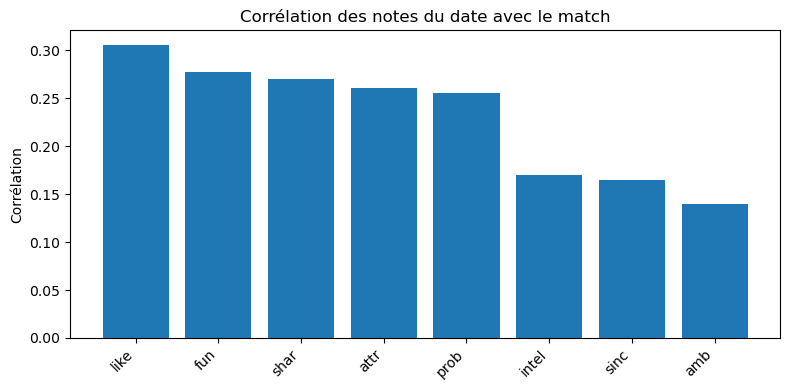

In [ ]:
rating_cols = ['attr','sinc','intel','fun','amb','shar','like','prob']

mean_by_match = df.groupby('match')[rating_cols].mean().T.rename(columns={0:'No match', 1:'Match'})
corr_match = df[rating_cols + ['match']].corr(numeric_only=True)['match'].drop('match').sort_values(ascending=False)
corr_dec = df[rating_cols + ['dec']].corr(numeric_only=True)['dec'].drop('dec').sort_values(ascending=False)

display(mean_by_match)
display(pd.DataFrame({
    'corr_with_dec': corr_dec,
    'corr_with_match': corr_match
}).sort_values('corr_with_match', ascending=False))

plt.figure(figsize=(8,4))
plt.bar(corr_match.index, corr_match.values)
plt.title("Corrélation des notes du date avec le match")
plt.ylabel("Corrélation")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Principaux constats

Le lecteur doit surtout comparer :
- les écarts de moyennes entre `match=0` et `match=1` ;
- les corrélations avec `dec` et `match`.

L'objectif n'est pas de conclure à une causalité stricte, mais d'identifier les signaux les plus associés à une issue positive.


## 5. Préférences déclarées avant l'événement : quelles qualités sont les moins valorisées ?

Le brief invite à comparer les qualités recherchées par les participants et à vérifier si cette hiérarchie diffère selon le genre.

### Point de méthode
Les vagues du dataset n'utilisent pas toutes la même échelle :
- certaines reposent sur une allocation de **100 points** ;
- d'autres sur une échelle **1–10**.

Pour rendre la comparaison cohérente, on travaille donc en **poids relatifs** au sein de chaque répondant.


gender,Femmes évaluant des hommes,Hommes évaluant des femmes
Attractiveness,18.06%,26.91%
Sincerity,18.31%,16.48%
Intelligence,21.01%,19.52%
Fun,17.15%,17.75%
Ambition,12.83%,8.50%
Shared interests,12.71%,10.97%


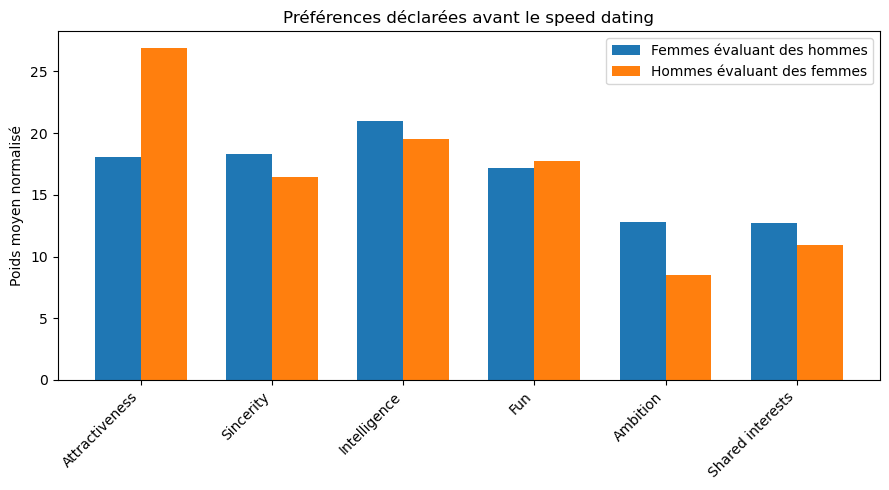

In [ ]:
pref_cols = ['attr1_1','sinc1_1','intel1_1','fun1_1','amb1_1','shar1_1']
pref_labels = {
    'attr1_1':'Attractiveness',
    'sinc1_1':'Sincerity',
    'intel1_1':'Intelligence',
    'fun1_1':'Fun',
    'amb1_1':'Ambition',
    'shar1_1':'Shared interests'
}

pref_work = df[['gender'] + pref_cols].copy()
pref_sum = pref_work[pref_cols].sum(axis=1)
for c in pref_cols:
    pref_work[c + '_share'] = np.where(pref_sum > 0, pref_work[c] / pref_sum * 100, np.nan)

pref_share_gender = (
    pref_work.groupby('gender')[[c + '_share' for c in pref_cols]]
             .mean()
             .rename(index={0:'Femmes évaluant des hommes', 1:'Hommes évaluant des femmes'})
             .T
)
pref_share_gender.index = [pref_labels[c.replace('_share', '')] for c in pref_share_gender.index]

display(pref_share_gender.style.format('{:.2f}%'))

plot_df = pref_share_gender.copy()
x = np.arange(len(plot_df.index))
width = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - width/2, plot_df.iloc[:,0], width, label=plot_df.columns[0])
plt.bar(x + width/2, plot_df.iloc[:,1], width, label=plot_df.columns[1])
plt.xticks(x, plot_df.index, rotation=45, ha='right')
plt.ylabel("Poids moyen normalisé")
plt.title("Préférences déclarées avant le speed dating")
plt.legend()
plt.tight_layout()
plt.show()

### Interprétation

L'enjeu n'est pas seulement de classer les qualités, mais de repérer celles qui arrivent **systématiquement en bas de hiérarchie**.

Cela permet de répondre proprement à la question du brief sans mélanger des échelles de réponse hétérogènes.


## 6. *Attractiveness* : importance déclarée, importance reconstruite et impact observé

L'attractivité est l'une des questions centrales du sujet.  
On l'aborde sous trois angles complémentaires :

1. **avant l'événement** : ce que les participants disent rechercher ;
2. **après l'événement** : ce qu'ils déclarent avoir réellement pris en compte ;
3. **dans les données observées** : ce qui est le plus associé à `dec`.

Cette comparaison permet d'opposer **discours déclaré** et **comportement observé**.


gender,Femmes,Hommes
Attractiveness,29.15%,37.41%
Sincerity,15.37%,11.71%
Intelligence,15.54%,14.99%
Fun,18.40%,19.39%
Ambition,8.19%,6.39%
Shared interests,13.79%,10.40%


gender,Femmes,Hommes
Attractiveness,0.445,0.515
Sincerity,0.222,0.191
Intelligence,0.233,0.217
Fun,0.417,0.407
Ambition,0.175,0.220
Shared interests,0.413,0.387


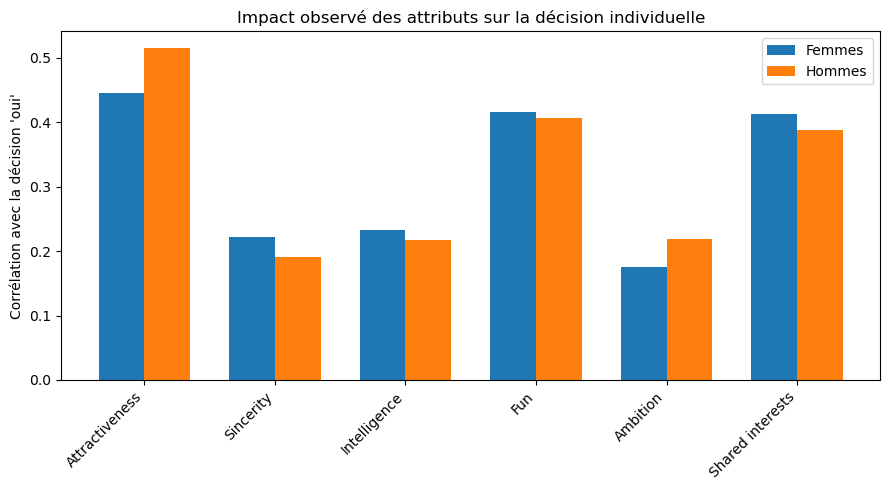

In [ ]:
post_cols = ['attr7_2','sinc7_2','intel7_2','fun7_2','amb7_2','shar7_2']
post_labels = {
    'attr7_2':'Attractiveness',
    'sinc7_2':'Sincerity',
    'intel7_2':'Intelligence',
    'fun7_2':'Fun',
    'amb7_2':'Ambition',
    'shar7_2':'Shared interests'
}

post_work = df[['gender'] + post_cols].copy()
post_sum = post_work[post_cols].sum(axis=1)
for c in post_cols:
    post_work[c + '_share'] = np.where(post_sum > 0, post_work[c] / post_sum * 100, np.nan)

post_share_gender = (
    post_work.groupby('gender')[[c + '_share' for c in post_cols]]
             .mean()
             .rename(index={0:'Femmes', 1:'Hommes'})
             .T
)
post_share_gender.index = [post_labels[c.replace('_share', '')] for c in post_share_gender.index]

obs_rows = []
for g in [0, 1]:
    sub = df[df['gender'] == g]
    for feat in ['attr','sinc','intel','fun','amb','shar']:
        temp = sub[[feat, 'dec']].dropna()
        obs_rows.append({
            'gender': 'Femmes' if g == 0 else 'Hommes',
            'feature': feat,
            'corr_with_dec': temp[feat].corr(temp['dec'])
        })

obs_impact = pd.DataFrame(obs_rows)
obs_pivot = obs_impact.pivot(index='feature', columns='gender', values='corr_with_dec').loc[['attr','sinc','intel','fun','amb','shar']]
obs_pivot.index = ['Attractiveness','Sincerity','Intelligence','Fun','Ambition','Shared interests']

display(post_share_gender.style.format('{:.2f}%'))
display(obs_pivot.style.format('{:.3f}'))

plot_df = obs_pivot.copy()
x = np.arange(len(plot_df.index))
width = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - width/2, plot_df['Femmes'], width, label='Femmes')
plt.bar(x + width/2, plot_df['Hommes'], width, label='Hommes')
plt.xticks(x, plot_df.index, rotation=45, ha='right')
plt.ylabel("Corrélation avec la décision 'oui'")
plt.title("Impact observé des attributs sur la décision individuelle")
plt.legend()
plt.tight_layout()
plt.show()

### Message principal

Le bon message n'est pas : *« tout se résume au physique »*.

Le bon message est plus nuancé :
- l'attractivité joue un rôle important ;
- mais elle est concurrencée par des dimensions relationnelles comme le **fun** et les **intérêts partagés** ;
- elle doit donc être lue comme un levier fort, mais **non exclusif**.


## 7. Intérêts partagés ou proximité démographique ?

Cette section répond à une autre question importante du brief :
les **intérêts partagés** comptent-ils davantage que la simple similarité démographique ?

On compare ici :
- `samerace` : une proximité démographique binaire ;
- `shar` : une compatibilité perçue pendant l'échange.

La comparaison est précieuse dans une logique produit, car elle oppose un signal **statique** à un signal **relationnel**.


,yes_rate,match_rate,n
samerace,,,
Race différente,41.07%,16.08%,5062
Même race,43.40%,17.07%,3316


,yes_rate,match_rate,n
shar_bin,,,
"(-0.001, 3.0]",13.71%,4.89%,1371
"(3.0, 5.0]",33.67%,9.83%,2248
"(5.0, 7.0]",54.06%,22.07%,2401
"(7.0, 10.0]",71.57%,34.24%,1291


,Signal,Match rate bas / ref,Match rate haut / exposé,Lift relatif
0,Même race,16.08%,17.07%,+6.1%
1,Shared interests : très haut vs très bas,4.89%,34.24%,+600.6%


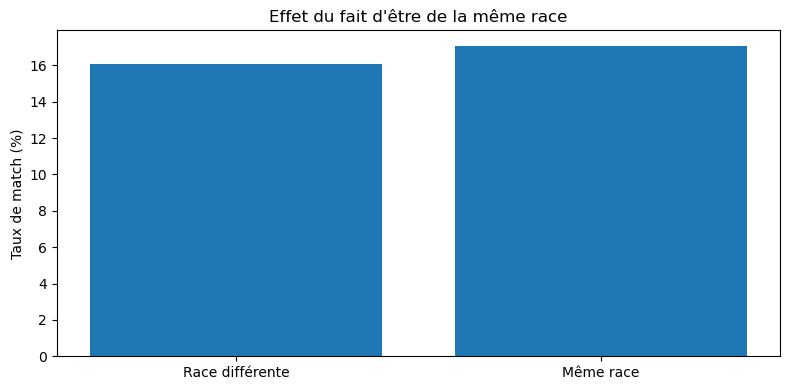

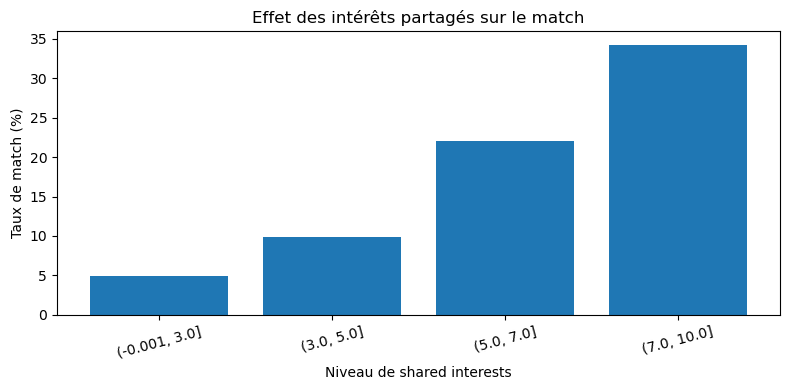

In [ ]:
same_race_summary = (
    df.groupby('samerace')
      .agg(
          yes_rate=('dec','mean'),
          match_rate=('match','mean'),
          n=('match','size')
      )
      .rename(index={0:'Race différente', 1:'Même race'})
)

shar_tmp = df[['shar','dec','match']].dropna().copy()
shar_tmp['shar_bin'] = pd.cut(shar_tmp['shar'], bins=[0,3,5,7,10], include_lowest=True)
shar_summary = shar_tmp.groupby('shar_bin', observed=False).agg(
    yes_rate=('dec','mean'),
    match_rate=('match','mean'),
    n=('match','size')
)

race_lift = (
    same_race_summary.loc['Même race', 'match_rate'] / same_race_summary.loc['Race différente', 'match_rate'] - 1
)

shar_lift = (
    shar_summary['match_rate'].iloc[-1] / shar_summary['match_rate'].iloc[0] - 1
)

effect_comparison = pd.DataFrame({
    'Signal': ['Même race', 'Shared interests : très haut vs très bas'],
    'Match rate bas / ref': [
        same_race_summary.loc['Race différente', 'match_rate'],
        shar_summary['match_rate'].iloc[0]
    ],
    'Match rate haut / exposé': [
        same_race_summary.loc['Même race', 'match_rate'],
        shar_summary['match_rate'].iloc[-1]
    ],
    'Lift relatif': [race_lift, shar_lift]
})

display(same_race_summary.style.format({'yes_rate':'{:.2%}','match_rate':'{:.2%}'}))
display(shar_summary.style.format({'yes_rate':'{:.2%}','match_rate':'{:.2%}'}))
display(effect_comparison.style.format({
    'Match rate bas / ref':'{:.2%}',
    'Match rate haut / exposé':'{:.2%}',
    'Lift relatif':'{:+.1%}'
}))

plt.figure(figsize=(8,4))
plt.bar(['Race différente', 'Même race'], same_race_summary['match_rate']*100)
plt.ylabel("Taux de match (%)")
plt.title("Effet du fait d'être de la même race")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.bar(shar_summary.index.astype(str), shar_summary['match_rate']*100)
plt.ylabel("Taux de match (%)")
plt.xlabel("Niveau de shared interests")
plt.title("Effet des intérêts partagés sur le match")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Lecture des résultats

Il faut surtout observer l'ampleur relative des effets :

- si `samerace` fait peu bouger le taux de match, son utilité produit est probablement limitée ;
- si `shar` crée un gradient fort, alors la compatibilité vécue pendant l'échange est un signal beaucoup plus puissant.


## 7.1. Vérification supplémentaire au niveau paire

Pour renforcer l'analyse, on passe du niveau ligne au **niveau paire** et on pose deux questions :

1. l'effet de `samerace` reste-t-il visible quand le niveau de `shared interests` est comparable ?
2. comment évolue le match quand l'attractivité moyenne du duo et les intérêts partagés moyens augmentent ensemble ?

Cette lecture évite de s'en tenir à une comparaison trop brute.


,shar_band,samerace,match_rate,n
0,Très bas,0,2.72%,331
1,Très bas,1,4.76%,147
2,Bas-moyen,0,6.65%,842
3,Bas-moyen,1,7.02%,541
4,Moyen-haut,0,21.52%,948
5,Moyen-haut,1,19.47%,647
6,Très haut,0,40.36%,337
7,Très haut,1,39.34%,272


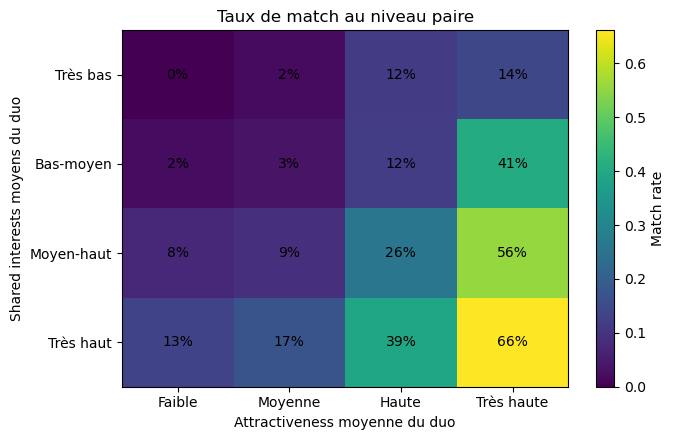

In [ ]:
pair_interest = pair_df[['match','samerace','shar_pair','attr_pair']].dropna().copy()

pair_interest['shar_band'] = pd.cut(
    pair_interest['shar_pair'],
    bins=[0,3,5,7,10],
    include_lowest=True,
    labels=['Très bas', 'Bas-moyen', 'Moyen-haut', 'Très haut']
)

pair_interest['attr_band'] = pd.cut(
    pair_interest['attr_pair'],
    bins=[0,4,6,8,10],
    include_lowest=True,
    labels=['Faible', 'Moyenne', 'Haute', 'Très haute']
)

race_within_shar = (
    pair_interest.groupby(['shar_band','samerace'], observed=False)
                 .agg(match_rate=('match','mean'), n=('match','size'))
                 .reset_index()
)
display(race_within_shar.style.format({'match_rate':'{:.2%}'}))

heat = pair_interest.pivot_table(
    index='shar_band',
    columns='attr_band',
    values='match',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(7,4.5))
im = ax.imshow(heat.values, aspect='auto')
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_xlabel("Attractiveness moyenne du duo")
ax.set_ylabel("Shared interests moyens du duo")
ax.set_title("Taux de match au niveau paire")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.0%}", ha='center', va='center')
plt.colorbar(im, ax=ax, label='Match rate')
plt.tight_layout()
plt.show()

### Interprétation

Cette étape sert à distinguer :
- une simple corrélation descriptive ;
- d'un signal plus robuste qui reste visible quand on change de niveau d'analyse.

Si l'effet de `shared interests` domine encore au niveau paire, alors l'argument produit devient plus crédible.


## 8. Les participants évaluent-ils correctement leur propre valeur sur le marché du dating ?

Le brief demande aussi si les individus savent correctement anticiper leur succès.

On l'étudie avec deux angles :
1. leur capacité à anticiper le nombre de matches attendus ;
2. l'écart entre certaines **auto-évaluations** et les **notes effectivement reçues**.


,metric,value
0,"Corr(expected_matches, actual_matches)",0.429
1,"Corr(self_attr, received_attr)",0.289
2,"Corr(self_fun, received_fun)",0.280
3,"Corr(self_intel, received_intel)",0.052
4,"Corr(self_sinc, received_sinc)",-0.011
5,"Corr(self_amb, received_amb)",0.158


,expected_matches,actual_matches,match_error
gender,,,
Femmes,2.88,2.52,0.44
Hommes,3.17,2.49,0.83


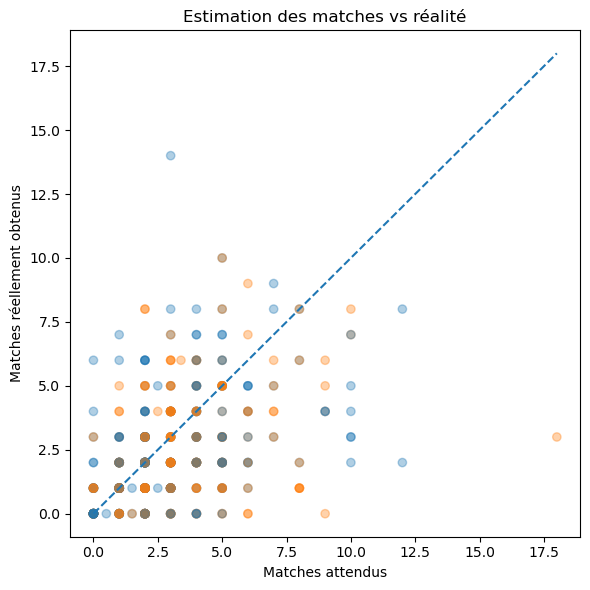

In [ ]:
person = (
    df.groupby('iid')
      .agg(
          gender=('gender','first'),
          dates=('dec','size'),
          expected_yes=('expnum','first'),
          expected_matches=('match_es','first'),
          actual_yes_received=('dec_o','sum'),
          actual_matches=('match','sum'),
          self_attr=('attr3_1','first'),
          self_sinc=('sinc3_1','first'),
          self_intel=('intel3_1','first'),
          self_fun=('fun3_1','first'),
          self_amb=('amb3_1','first'),
          received_attr=('attr_o','mean'),
          received_sinc=('sinc_o','mean'),
          received_intel=('intel_o','mean'),
          received_fun=('fun_o','mean'),
          received_amb=('amb_o','mean'),
      )
      .reset_index()
)

corr_match_est = person[['expected_matches','actual_matches']].dropna().corr().iloc[0,1]

self_vs_received = {}
for feat in ['attr','sinc','intel','fun','amb']:
    temp = person[[f'self_{feat}', f'received_{feat}']].dropna()
    self_vs_received[feat] = temp.corr().iloc[0,1]

person['match_error'] = person['expected_matches'] - person['actual_matches']
bias_by_gender = (
    person.groupby('gender')[['expected_matches','actual_matches','match_error']]
          .mean()
          .rename(index={0:'Femmes', 1:'Hommes'})
)

display(pd.DataFrame({
    'metric': [
        'Corr(expected_matches, actual_matches)',
        'Corr(self_attr, received_attr)',
        'Corr(self_fun, received_fun)',
        'Corr(self_intel, received_intel)',
        'Corr(self_sinc, received_sinc)',
        'Corr(self_amb, received_amb)',
    ],
    'value': [
        corr_match_est,
        self_vs_received['attr'],
        self_vs_received['fun'],
        self_vs_received['intel'],
        self_vs_received['sinc'],
        self_vs_received['amb'],
    ]
}).style.format({'value':'{:.3f}'}))

display(bias_by_gender.style.format('{:.2f}'))

plot_people = person[['expected_matches','actual_matches','gender']].dropna()
colors = plot_people['gender'].map({0:'tab:blue', 1:'tab:orange'})

plt.figure(figsize=(6,6))
plt.scatter(plot_people['expected_matches'], plot_people['actual_matches'], alpha=0.35, c=colors)
maxv = max(plot_people['expected_matches'].max(), plot_people['actual_matches'].max())
plt.plot([0, maxv], [0, maxv], linestyle='--')
plt.xlabel("Matches attendus")
plt.ylabel("Matches réellement obtenus")
plt.title("Estimation des matches vs réalité")
plt.tight_layout()
plt.show()


### Ce que montrent les données

L'idée n'est pas de juger les participants, mais d'évaluer leur **calibration** :

- sont-ils proches de la réalité ?
- se surestiment-ils ?
- ou sous-estiment-ils leur succès probable ?

Le résultat attendu est donc nuancé : lucidité partielle ou biais systématique.


## 8.1. Calibration : niveau d'optimisme et qualité d'auto-évaluation

La corrélation donne un premier signal, mais elle ne suffit pas.  
On complète l'analyse avec une logique de **taux attendu** versus **taux réel**, afin de comparer proprement des participants qui n'ont pas tous rencontré le même nombre de personnes.


,expected_rate,actual_rate,bias,mae,n
gender,,,,,
Femmes,20.03%,16.49%,3.54%,11.64%,240
Hommes,23.18%,16.02%,7.15%,12.84%,239


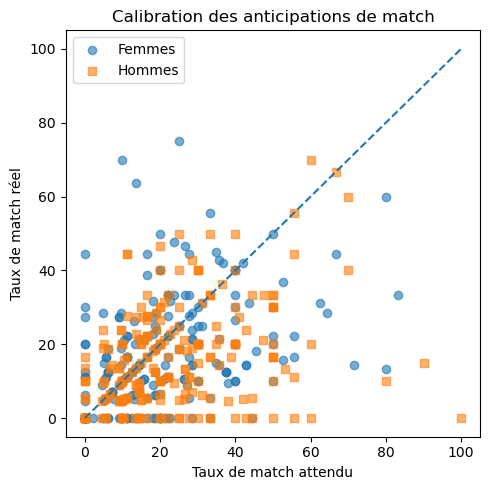

In [ ]:
calib = person[['gender','dates','expected_matches','actual_matches']].dropna().copy()
calib = calib[calib['dates'] > 0]

calib['expected_rate'] = calib['expected_matches'] / calib['dates']
calib['actual_rate'] = calib['actual_matches'] / calib['dates']
calib['bias'] = calib['expected_rate'] - calib['actual_rate']
calib['abs_error'] = (calib['bias']).abs()

calib_summary = (
    calib.groupby('gender')
         .agg(
             expected_rate=('expected_rate','mean'),
             actual_rate=('actual_rate','mean'),
             bias=('bias','mean'),
             mae=('abs_error','mean'),
             n=('bias','size')
         )
         .rename(index={0:'Femmes', 1:'Hommes'})
)
display(calib_summary.style.format({'expected_rate':'{:.2%}','actual_rate':'{:.2%}','bias':'{:.2%}','mae':'{:.2%}'}))

plt.figure(figsize=(5,5))
for g, label, marker in [(0, 'Femmes', 'o'), (1, 'Hommes', 's')]:
    sub = calib[calib['gender'] == g]
    plt.scatter(sub['expected_rate']*100, sub['actual_rate']*100, alpha=0.6, label=label, marker=marker)
lim = max(calib['expected_rate'].max(), calib['actual_rate'].max()) * 100
plt.plot([0, lim], [0, lim], linestyle='--')
plt.xlabel("Taux de match attendu")
plt.ylabel("Taux de match réel")
plt.title("Calibration des anticipations de match")
plt.legend()
plt.tight_layout()
plt.show()

### Interprétation

Cette lecture permet de distinguer deux idées :
- les participants disposent d'une **intuition partielle** de leur succès potentiel ;
- mais cette intuition reste **imparfaitement calibrée**, avec une tendance moyenne à la surestimation.

C'est une réponse plus précise que le simple constat d'une corrélation positive.


## 9. Effet de l'ordre de passage dans la soirée

Le brief suggère de tester si être vu **tôt** ou **tard** dans la soirée peut influencer l'issue d'un rendez-vous.

Pour éviter une lecture trompeuse, on ne compare pas seulement l'ordre brut.  
On construit aussi un **ordre relatif**, afin de rendre comparables des soirées qui n'ont pas le même nombre de rounds.


,yes_rate,match_rate,n
order_bin,,,
Début,42.57%,17.22%,2765
Milieu,43.05%,16.67%,2639
Fin,40.52%,15.60%,2974


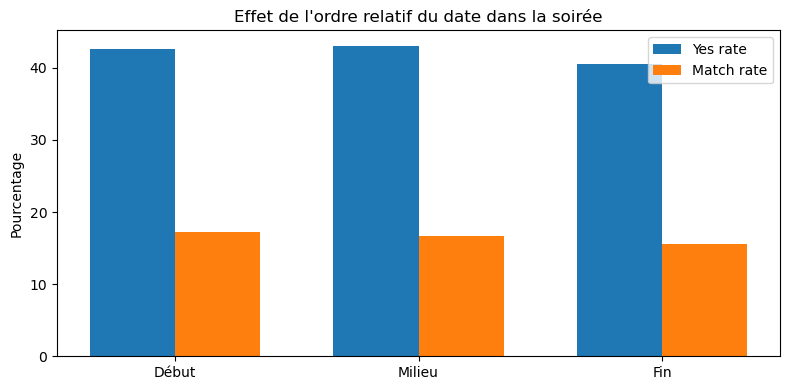

Corr(order, dec)   = -0.032
Corr(order, match) = -0.039
Corr(relative_order, match) = -0.02


In [ ]:
order_tmp = df[['order','round','dec','match']].dropna().copy()
order_tmp = order_tmp[order_tmp['round'] > 1]

order_tmp['relative_order'] = (order_tmp['order'] - 1) / (order_tmp['round'] - 1)
order_tmp['order_bin'] = pd.cut(
    order_tmp['relative_order'],
    bins=[-0.01, 0.33, 0.66, 1.0],
    labels=['Début', 'Milieu', 'Fin']
)

order_summary = order_tmp.groupby('order_bin', observed=False).agg(
    yes_rate=('dec','mean'),
    match_rate=('match','mean'),
    n=('match','size')
)

display(order_summary.style.format({'yes_rate':'{:.2%}', 'match_rate':'{:.2%}'}))

x = np.arange(len(order_summary.index))
width = 0.35

plt.figure(figsize=(8,4))
plt.bar(x - width/2, order_summary['yes_rate']*100, width, label='Yes rate')
plt.bar(x + width/2, order_summary['match_rate']*100, width, label='Match rate')
plt.xticks(x, order_summary.index)
plt.ylabel("Pourcentage")
plt.title("Effet de l'ordre relatif du date dans la soirée")
plt.legend()
plt.tight_layout()
plt.show()

print("Corr(order, dec)   =", round(order_tmp['order'].corr(order_tmp['dec']), 3))
print("Corr(order, match) =", round(order_tmp['order'].corr(order_tmp['match']), 3))
print("Corr(relative_order, match) =", round(order_tmp['relative_order'].corr(order_tmp['match']), 3))


### Résultat

Si un effet existe, il doit être interprété comme un **effet de contexte** :
fatigue, saturation, baisse d'attention en fin de soirée, etc.

La question importante est donc moins de savoir si l'effet existe que de mesurer **son poids relatif** par rapport aux signaux majeurs du projet.


## 10. Quelques variables de contexte disponibles avant la rencontre

Pour compléter l'analyse, on examine des variables potentiellement mobilisables **avant même l'échange**, comme l'écart d'âge.

L'objectif est de comparer leur apport à celui des variables construites pendant l'interaction.


,yes_rate,match_rate,n
gap_bin,,,
0-1,44.29%,18.87%,2226
2-3,43.02%,17.79%,2406
4-5,41.49%,15.62%,1728
6+,38.50%,12.50%,1808


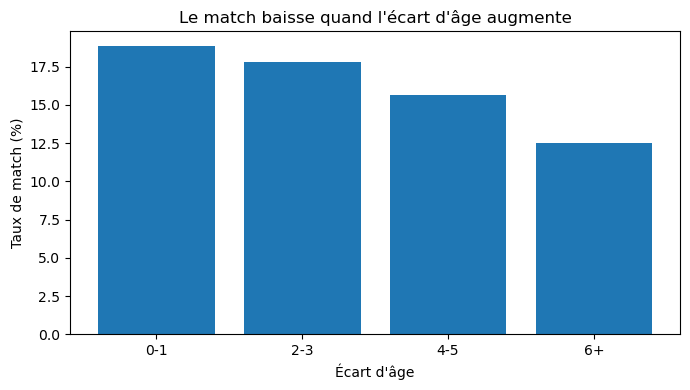

In [ ]:
df['age_gap'] = (df['age'] - df['age_o']).abs()
agegap = df[['age_gap','dec','match']].dropna().copy()
agegap['gap_bin'] = pd.cut(agegap['age_gap'], bins=[-0.1,1,3,5,20], labels=['0-1','2-3','4-5','6+'])

agegap_summary = agegap.groupby('gap_bin', observed=False).agg(
    yes_rate=('dec','mean'),
    match_rate=('match','mean'),
    n=('match','size')
)

display(agegap_summary.style.format({'yes_rate':'{:.2%}', 'match_rate':'{:.2%}'}))

plt.figure(figsize=(7,4))
plt.bar(agegap_summary.index.astype(str), agegap_summary['match_rate']*100)
plt.ylabel("Taux de match (%)")
plt.xlabel("Écart d'âge")
plt.title("Le match baisse quand l'écart d'âge augmente")
plt.tight_layout()
plt.show()

### Lecture

L'écart d'âge n'est pas présenté ici comme un levier central.  
Il s'agit plutôt d'un signal de contexte susceptible d'améliorer marginalement une logique de matching ex ante.


## 11. Bonus de modélisation : profil seul vs impressions du rendez-vous

Le sujet n'exige pas de machine learning, mais ce bonus apporte un éclairage utile au storytelling final.

Trois blocs sont comparés :
- **modèle A** : variables de profil / contexte avant la rencontre ;
- **modèle B** : impressions du rendez-vous ;
- **modèle C** : combinaison des deux.

### Choix méthodologique
Pour limiter un optimisme artificiel, l'évaluation est faite via des splits **par participant** (`iid`) et non via un simple split aléatoire par ligne.


,model,roc_auc_mean,roc_auc_std,accuracy_mean,f1_mean
1,Impressions du date,0.776,0.009,0.694,0.438
2,Profil + date,0.774,0.006,0.706,0.441
0,Profil / contexte,0.565,0.008,0.564,0.277


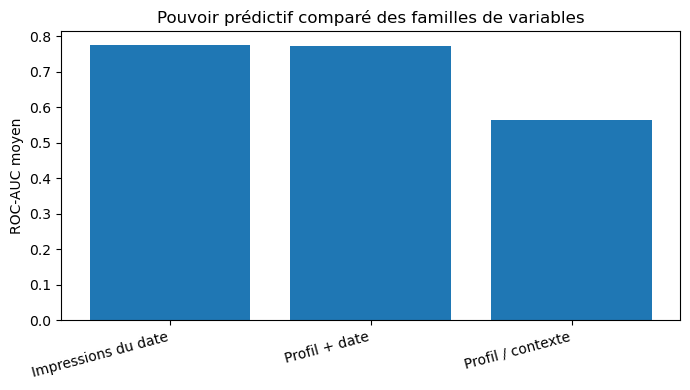

,feature,importance
35,like,0.0471
29,attr,0.0294
36,prob,0.0273
32,fun,0.0238
34,shar,0.0082
33,amb,0.0072
20,clubbing,0.0054
31,intel,0.0041
17,art,0.0040
16,museums,0.0028


In [ ]:
def evaluate_logreg_grouped(data, target, features, group_col='iid', n_splits=5, random_state=42):
    work = data[features + [target, group_col]].copy()
    X = work[features]
    y = work[target].astype(int)
    groups = work[group_col]

    splitter = GroupShuffleSplit(n_splits=n_splits, test_size=0.25, random_state=random_state)

    fold_rows = []
    fitted_pipe = None
    X_test_last = None
    y_test_last = None

    for fold, (train_idx, test_idx) in enumerate(splitter.split(X, y, groups), start=1):
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
        ])

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        proba = pipe.predict_proba(X_test)[:, 1]

        fold_rows.append({
            'fold': fold,
            'roc_auc': roc_auc_score(y_test, proba),
            'accuracy': accuracy_score(y_test, pred),
            'f1': f1_score(y_test, pred),
        })

        fitted_pipe = pipe
        X_test_last = X_test
        y_test_last = y_test

    return pd.DataFrame(fold_rows), fitted_pipe, X_test_last, y_test_last

profile_features = [c for c in [
    'gender','age','age_o','samerace','order','int_corr','imprace','imprelig',
    'date','go_out','exphappy','expnum',
    'sports','tvsports','exercise','dining','museums','art','hiking',
    'gaming','clubbing','reading','tv','theater','movies','concerts',
    'music','shopping','yoga'
] if c in df.columns]

date_features = [c for c in ['attr','sinc','intel','fun','amb','shar','like','prob'] if c in df.columns]
combined_features = profile_features + date_features

cv_profile, _, _, _ = evaluate_logreg_grouped(df, 'match', profile_features)
cv_date, _, _, _ = evaluate_logreg_grouped(df, 'match', date_features)
cv_combined, fitted_combined, X_test_last, y_test_last = evaluate_logreg_grouped(df, 'match', combined_features)

model_results = pd.DataFrame([
    {
        'model':'Profil / contexte',
        'roc_auc_mean':cv_profile['roc_auc'].mean(),
        'roc_auc_std':cv_profile['roc_auc'].std(),
        'accuracy_mean':cv_profile['accuracy'].mean(),
        'f1_mean':cv_profile['f1'].mean(),
    },
    {
        'model':'Impressions du date',
        'roc_auc_mean':cv_date['roc_auc'].mean(),
        'roc_auc_std':cv_date['roc_auc'].std(),
        'accuracy_mean':cv_date['accuracy'].mean(),
        'f1_mean':cv_date['f1'].mean(),
    },
    {
        'model':'Profil + date',
        'roc_auc_mean':cv_combined['roc_auc'].mean(),
        'roc_auc_std':cv_combined['roc_auc'].std(),
        'accuracy_mean':cv_combined['accuracy'].mean(),
        'f1_mean':cv_combined['f1'].mean(),
    },
]).sort_values('roc_auc_mean', ascending=False)

display(model_results.style.format({
    'roc_auc_mean':'{:.3f}',
    'roc_auc_std':'{:.3f}',
    'accuracy_mean':'{:.3f}',
    'f1_mean':'{:.3f}'
}))

plt.figure(figsize=(7,4))
plt.bar(model_results['model'], model_results['roc_auc_mean'])
plt.ylabel("ROC-AUC moyen")
plt.title("Pouvoir prédictif comparé des familles de variables")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

perm = permutation_importance(
    fitted_combined,
    X_test_last,
    y_test_last,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'feature': combined_features,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=False)

display(perm_df.head(12).style.format({'importance':'{:.4f}'}))


### Enseignement du bonus

Ce bonus ne sert pas à produire un modèle industrialisable.  
Il sert à répondre, de manière quantitative, à une question simple :

> le résultat final est-il mieux expliqué par le **profil** ou par l'**interaction vécue** ?

C'est ce qui lui donne sa valeur dans le cadre d'un projet exploratoire.


## 12. Réponse synthétique à la problématique produit

À ce stade, l'analyse permet de répondre directement à la question initiale.

Ce qui semble faire monter la probabilité d'un second rendez-vous n'est pas seulement la similarité de profil, mais surtout la qualité de l'interaction :
- une bonne impression globale ;
- une rencontre perçue comme agréable ;
- des intérêts partagés ;
- et une attractivité perçue suffisante.


## 13. Recommandations business

Les résultats suggèrent plusieurs implications pour une application de rencontre :

1. **ne pas surinvestir les variables démographiques brutes** ;
2. **mieux valoriser les signaux de compatibilité concrète** ;
3. **traiter les variables de profil comme des priors faibles** ;
4. **construire des expériences qui favorisent la qualité d'interaction** ;
5. **considérer les effets de séquencement comme secondaires**.


## 13.1. Scorecard de priorisation des signaux

Le tableau suivant résume les variables ou familles de variables selon trois dimensions :
- la force apparente du signal ;
- son caractère potentiellement actionnable ;
- la prudence d'interprétation à conserver.

L'objectif est de conclure sur une vision **opérationnelle** et non uniquement descriptive.


In [ ]:
scorecard = pd.DataFrame([
    ['Attractiveness perçue pendant le date', 'Fort', 'Oui', 'Signal important, mais pas suffisant seul'],
    ['Fun / qualité de l’échange', 'Fort', 'Oui', 'Très lié aux issues positives'],
    ['Shared interests perçus', 'Fort', 'Oui', 'Plus utile que la simple similarité démographique'],
    ['Même race', 'Faible', 'Avec prudence', 'Effet faible et peu stable face aux signaux relationnels'],
    ['Ordre du date dans la soirée', 'Faible à modéré', 'Secondaire', 'Effet cohérent mais non dominant'],
    ['Variables de profil seules', 'Faible', 'Limité', 'Pouvoir explicatif inférieur aux signaux d’interaction'],
    ['Auto-prédiction du succès', 'Imparfait', 'Non directement', 'Les participants sont partiellement mais mal calibrés']
], columns=['Signal', 'Niveau d’évidence', 'Action produit ?', 'Lecture business'])

display(scorecard)

,Signal,Niveau d’évidence,Action produit ?,Lecture business
0,Attractiveness perçue pendant le date,Fort,Oui,"Signal important, mais pas suffisant seul"
1,Fun / qualité de l’échange,Fort,Oui,Très lié aux issues positives
2,Shared interests perçus,Fort,Oui,Plus utile que la simple similarité démographique
3,Même race,Faible,Avec prudence,Effet faible et peu stable face aux signaux re...
4,Ordre du date dans la soirée,Faible à modéré,Secondaire,Effet cohérent mais non dominant
5,Variables de profil seules,Faible,Limité,Pouvoir explicatif inférieur aux signaux d’int...
6,Auto-prédiction du succès,Imparfait,Non directement,Les participants sont partiellement mais mal c...


## 14. Limites et précautions d'interprétation

Comme tout projet sérieux, cette analyse doit expliciter ses limites :

1. le dataset provient d'un **speed dating expérimental** datant du début des années 2000 ;
2. plusieurs variables fortes sont recueillies **après interaction** ;
3. les observations ne sont pas totalement indépendantes ;
4. certaines colonnes comportent beaucoup de valeurs manquantes ;
5. les questionnaires n'utilisent pas toujours les mêmes échelles selon les vagues.

Ces limites ne remettent pas en cause l'intérêt du projet, mais elles encadrent la portée des conclusions.


# Conclusion

L'analyse met en évidence une idée simple mais importante : le succès d'une rencontre ne se résume pas à la proximité de profil.

Les signaux les plus convaincants sont surtout :
- l'appréciation globale de la rencontre ;
- le **fun** ;
- les **intérêts partagés** ;
- et l'attractivité perçue.

À l'inverse, les variables de profil seules expliquent relativement peu le résultat final.

Dans une logique produit, cela plaide pour des systèmes de matching qui cherchent moins à rapprocher des profils simplement « semblables » qu'à favoriser les combinaisons de profils susceptibles de générer une interaction fluide, agréable et réciproque.
